# Exploratory Data Analysis

## CRISP-DM Phase 2A: Data Understanding

### Project: Customer Churn Analysis

Exploratory Data Analysis (EDA) is performed to understand customer behavior and identify pattern associated with customer churn.

The objective of this notebook is not only to visualize the dataset but also to answer business questions and identify actionable insights.

### EDA Objectives

- Understand the distribution of customer churn.
- Analyze customer demographics.
- Examine customer tenure.
- Investigate contract types.
- Analyze services used by customers.
- Examine billing and payment behavior.
- Identify customer segments with high churn rates.
- Identify potential drivers of churn.
- Generate actionable business recommendations.

Each analysis follows the structure:

**Business Question → Analysis → Visualization → Finding → Business Implication**

**Note:** Exploratory Data Analysis was performed after the data cleaning and preparation step to ensure that the analysis was based on a consistent and reliable dataset.

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Database connection
import os
from pathlib import Path
import sys

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))
from config.database import DB_CONFIG
from sqlalchemy import create_engine

# Display settings
pd.set_option("display.max_columns", None)

# Plot settings
plt.style.use("ggplot")

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Load Cleaned Dataset

The cleaned dataset produced during the Data Cleaning phase is stored in PostgreSQL as:

`customer_churn_clean`

Loading the dataset from PostgreSQL demonstrates the transition from data preparation to analytical data consumption.

The processed CSV remains available as a reproducibility artifact.

In [3]:
engine = create_engine(
    f"postgresql://{DB_CONFIG["user"]}:{DB_CONFIG["password"]}@{DB_CONFIG["host"]}:{DB_CONFIG["port"]}/{DB_CONFIG["database"]}"
)

query = "SELECT * FROM customer_churn_clean;"
df = pd.read_sql(query, engine)
print("Dataset loaded successfully.")

Dataset loaded successfully.


In [4]:
df.head()

,customerid,count,country,state,city,zip_code,lat_long,latitude,longitude,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_label,churn_value,churn_score,cltv,churn_reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


In [5]:
# Basic Summary

eda_summary = pd.DataFrame({
    "Metric":[
        "Number of Customers",
        "Number of features",
        "Missing Values",
        "Duplicate Rows"
    ],
    "Value":[
        df.shape[0],
        df.shape[1],
        df.isna().sum().sum(),
        df.duplicated().sum()
    ]
})
eda_summary

,Metric,Value
0,Number of Customers,7043
1,Number of features,33
2,Missing Values,0
3,Duplicate Rows,0


## 2. Target Variable

The target variable for this project is `churn`.

It indicates whether a customer has discontinued their service.

- `Yes` → Customer churned
- `No` → Customer remained with the company

Understanding the distribution of this variable is the first step in the churn analysis.

In [6]:
print("Churn Amount")
print(df['churn_label'].value_counts())
print()
print("Percentage of churn")

churn_percentage = (
    df['churn_label'].value_counts(normalize = True)
    .mul(100)
    .round(2)
)
print(churn_percentage)

Churn Amount
churn_label
No     5174
Yes    1869
Name: count, dtype: int64

Percentage of churn
churn_label
No     73.46
Yes    26.54
Name: proportion, dtype: float64


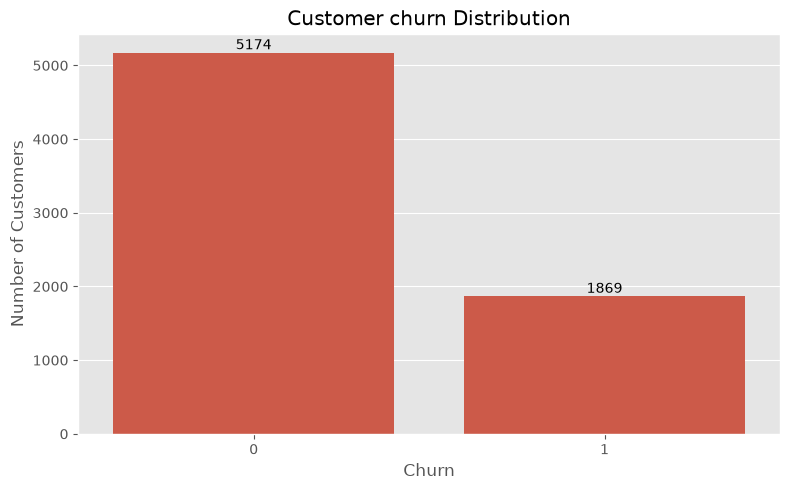

In [7]:
# Visualize the Target vaiable
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data = df,
    x = 'churn_value'
)
plt.title("Customer churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

## Finding: Overall Churn

Approximately 26.5% of customers in the dataset have churned, while approximately 73.5% have remained with the company.
This indicates that customer churn represents a significant business issue.

### Business Implication

The company has a substantial customer retention opportunity. Identifying the characteristics and behaviors associated with churn can help the business develop targeted retention strategies rather than applying the same intervention to all customers.


In [8]:
# Reusable Churn function
def churn_rate_by(column):
    result = (
        df.groupby(column)["churn_label"]
        .value_counts(normalize=True)
        .unstack(fill_value=0)
    )
    
    if "Yes" in result.columns:
        result["churn_rate"] = result["Yes"] * 100
    
    return result.sort_values(
        "churn_rate",
        ascending=False
    )

churn_rate_by('contract')

churn_label,No,Yes,churn_rate
contract,,,
Month-to-month,0.572903,0.427097,42.709677
One year,0.887305,0.112695,11.269518
Two year,0.971681,0.028319,2.831858


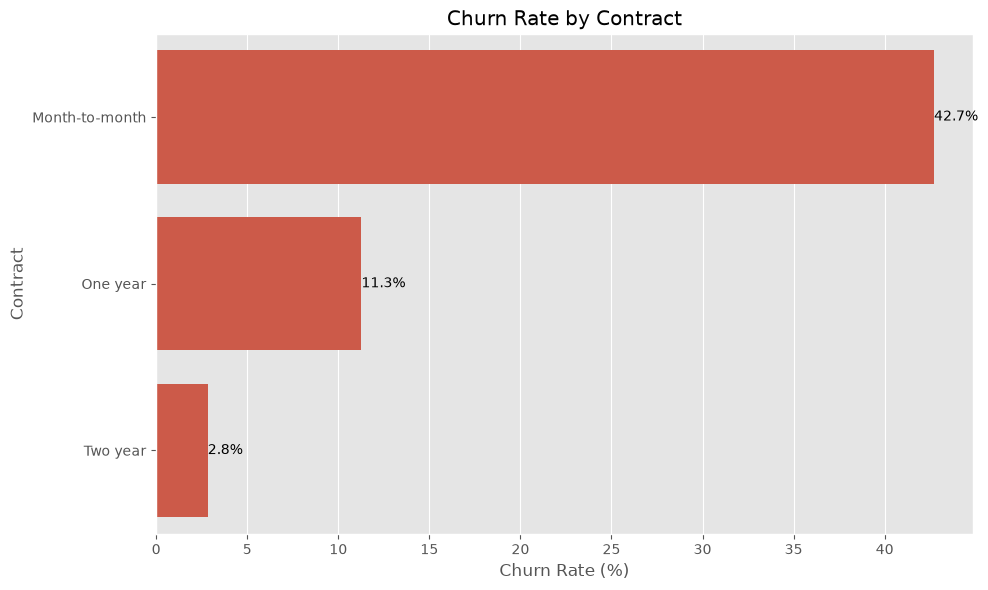

In [9]:
# Reusable Visualization function
def plot_churn_rate(column, title=None):
    
    churn_rate = (
        df.groupby(column)["churn_label"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .sort_values(ascending=False)
    )
    
    plt.figure(figsize=(10, 6))
    
    ax = sns.barplot(
        x=churn_rate.values,
        y=churn_rate.index
    )
    
    plt.xlabel("Churn Rate (%)")
    plt.ylabel(column.replace("_", " ").title())
    
    if title:
        plt.title(title)
    else:
        plt.title(
            f"Churn Rate by {column.replace('_', ' ').title()}"
        )
    
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.1f%%"
        )
    
    plt.tight_layout()
    plt.show()

plot_churn_rate("contract")

## 3. Demographic Analysis

### 3.1 Gender

### Business Question

**Does customer gender have a meaningful relationship with churn?**

The analysis compares the number of customers and churn rate between male
and female customers.

Churn rate is used instead of raw churn counts because the two groups may
have different numbers of customers.

In [10]:
gender_distribution = df['gender'].value_counts()
gender_distribution

gender
Male      3555
Female    3488
Name: count, dtype: int64

In [11]:
# Calculate Churn by gender
gender_churn = churn_rate_by('gender')
gender_churn

churn_label,No,Yes,churn_rate
gender,,,
Female,0.730791,0.269209,26.920872
Male,0.738397,0.261603,26.160338


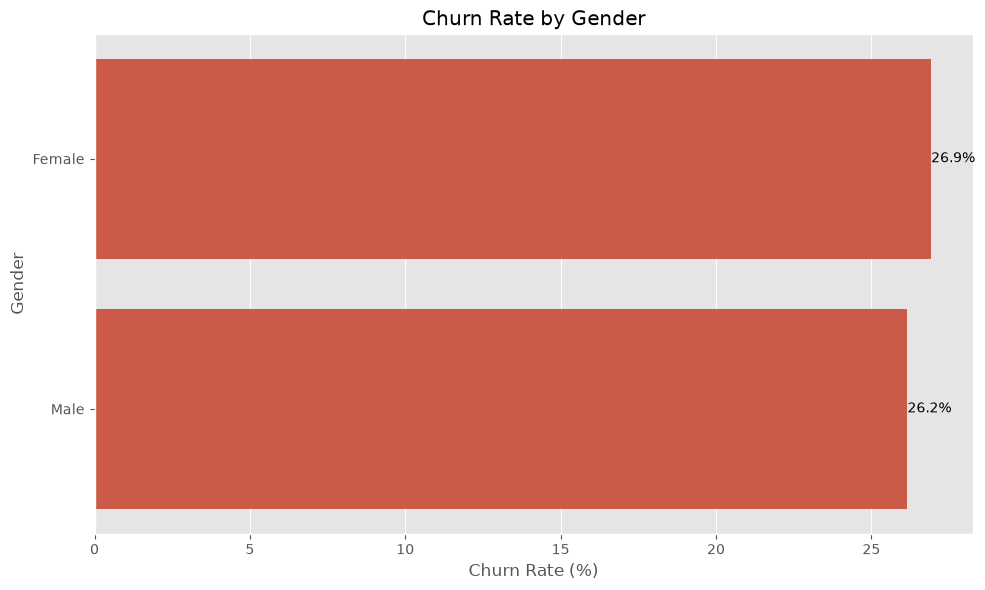

In [12]:
# Plot Churn by gender 
plot_churn_rate('gender', 'Churn Rate by Gender')

### Finding

The churn rates for male and female customers are relatively similar.
Although there may be a small difference between the two groups, the
difference is not large enough to suggest that gender is a major standalone
driver of customer churn.

### Business Implication

Gender alone does not appear to provide strong evidence for targeting
customers with retention interventions. Other characteristics such as
contract type, tenure, services, and billing behavior are likely to provide
more actionable insights.

### 3.2 Senior Citizen

### Business Question
**Are senior citizens more likely to churn than non-senior customers?**

The `senior_citizen` variable indicates whether the customer belongs to the senior-citizen segment.

In [13]:
senior_citizen_dist = df['senior_citizen'].value_counts()
senior_citizen_dist

senior_citizen
No     5901
Yes    1142
Name: count, dtype: int64

In [14]:
# Calculate Churn by senior citizen
churn_by_senior_citizen = churn_rate_by('senior_citizen')
churn_by_senior_citizen

churn_label,No,Yes,churn_rate
senior_citizen,,,
Yes,0.583187,0.416813,41.681261
No,0.763938,0.236062,23.606168


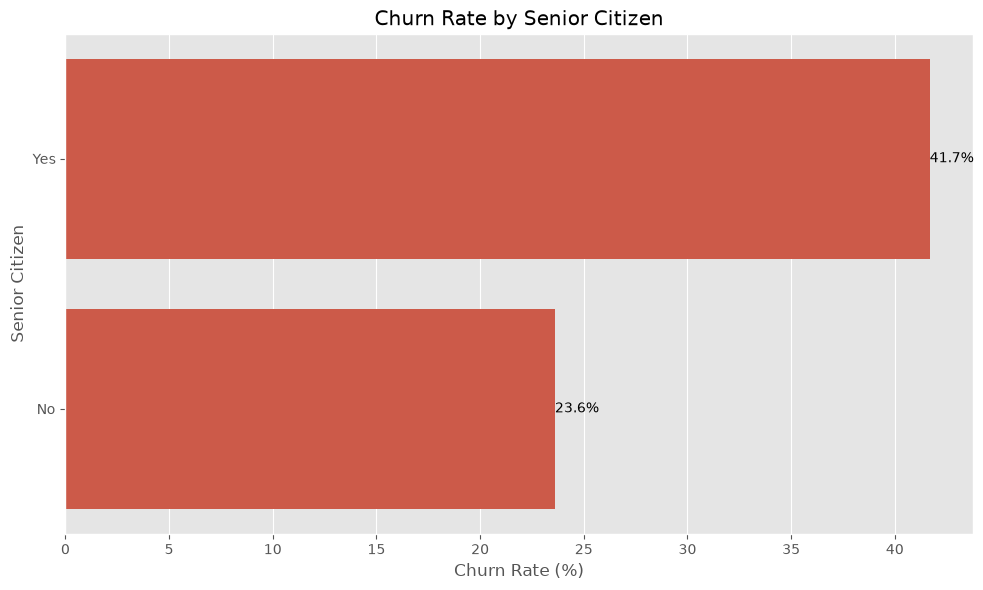

In [15]:
plot_churn_rate('senior_citizen', 'Churn Rate by Senior Citizen')

### 3.3 Partner Status

### Business Question

**Does having a partner influence customer churn?**

Customers are divided into two groups:

- Customers with a partner
- Customers without a partner

In [16]:
partner_dist = df['partner'].value_counts()
partner_dist

partner
No     3641
Yes    3402
Name: count, dtype: int64

In [17]:
churn_by_partner = churn_rate_by('partner')
churn_by_partner

churn_label,No,Yes,churn_rate
partner,,,
No,0.670420,0.329580,32.957979
Yes,0.803351,0.196649,19.664903


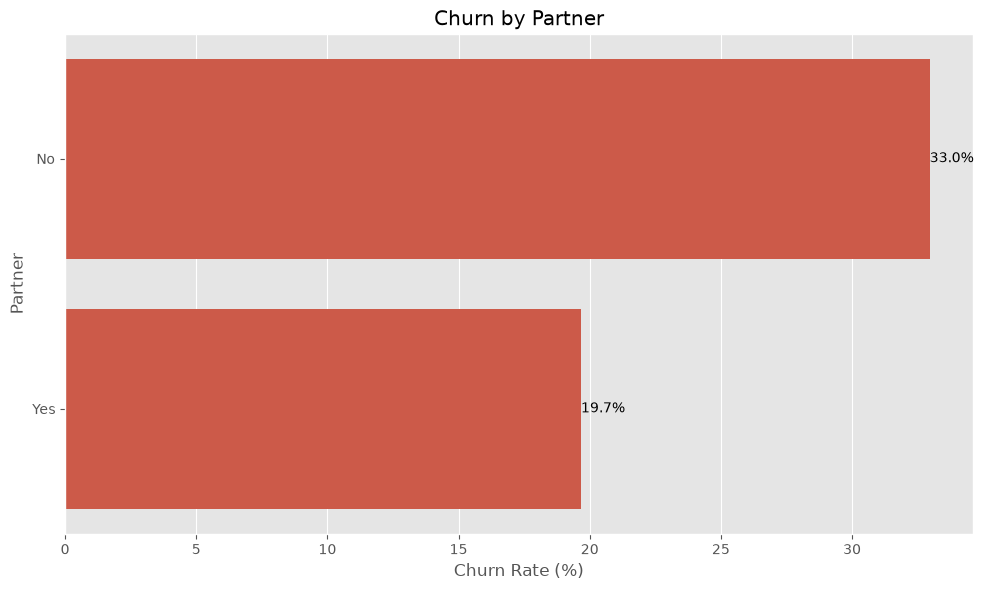

In [18]:
plot_churn_rate('partner', 'Churn by Partner')

### Finding

Customers without a partner show a higher churn rate than customers who
have a partner.

### Business Implication

Partner status may act as an indicator of customer stability or customer
lifecycle stage. However, it should be combined with other behavioral and
service-related variables before making retention decisions.

### 5.4 Dependents

### Business Question

**Does having dependents influence customer churn?**

The analysis compares churn rates between customers with and without
dependents.

In [19]:
df['dependents'].value_counts()

dependents
No     5416
Yes    1627
Name: count, dtype: int64

In [20]:
churn_rate_by_dependents = churn_rate_by('dependents')
churn_rate_by_dependents

churn_label,No,Yes,churn_rate
dependents,,,
No,0.674483,0.325517,32.551699
Yes,0.934849,0.065151,6.515058


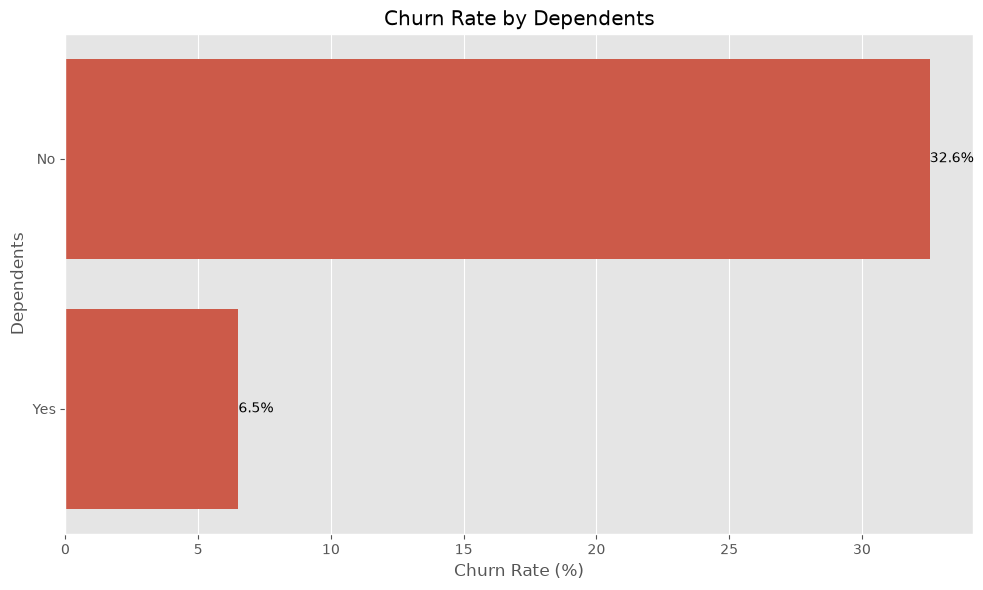

In [21]:
plot_churn_rate('dependents')

### Finding

Customers without dependents have a higher churn rate than customers with
dependents.

### Business Implication

Customers without dependents may represent a higher-risk segment. The
business could investigate whether their service usage patterns, contract
preferences, or pricing sensitivity differ from customers with dependents.

In [22]:
demographic_summary = pd.DataFrame({
    "Variable": [
        "Gender",
        "Senior Citizen",
        "Partner",
        "Dependents"
    ],
    "Analysis": [
        "Gender vs Churn",
        "Senior Citizen vs Churn",
        "Partner vs Churn",
        "Dependents vs Churn"
    ]
})

demographic_summary

,Variable,Analysis
0,Gender,Gender vs Churn
1,Senior Citizen,Senior Citizen vs Churn
2,Partner,Partner vs Churn
3,Dependents,Dependents vs Churn


In [27]:
demographic_variables = {
    "Gender": "gender",
    "Senior Citizen": "senior_citizen",
    "Partner": "partner",
    "Dependents": "dependents"
}

demographic_results = []
for label, column in demographic_variables.items():
    result = churn_rate_by(column)
    highest = result.iloc[0]
    lowest = result.iloc[-1]
    demographic_results.append({
        "Variable": label,
        "Highest Churn Category": highest.name,
        "Highest Churn Rate": round(highest["churn_rate"], 2),
        "Lowest Churn Category": lowest.name,
        "Lowest Churn Rate": round(lowest["churn_rate"], 2)
    })
demographic_results = pd.DataFrame(demographic_results)
demographic_results

,Variable,Highest Churn Category,Highest Churn Rate,Lowest Churn Category,Lowest Churn Rate
0,Gender,Female,26.92,Male,26.16
1,Senior Citizen,Yes,41.68,No,23.61
2,Partner,No,32.96,Yes,19.66
3,Dependents,No,32.55,Yes,6.52


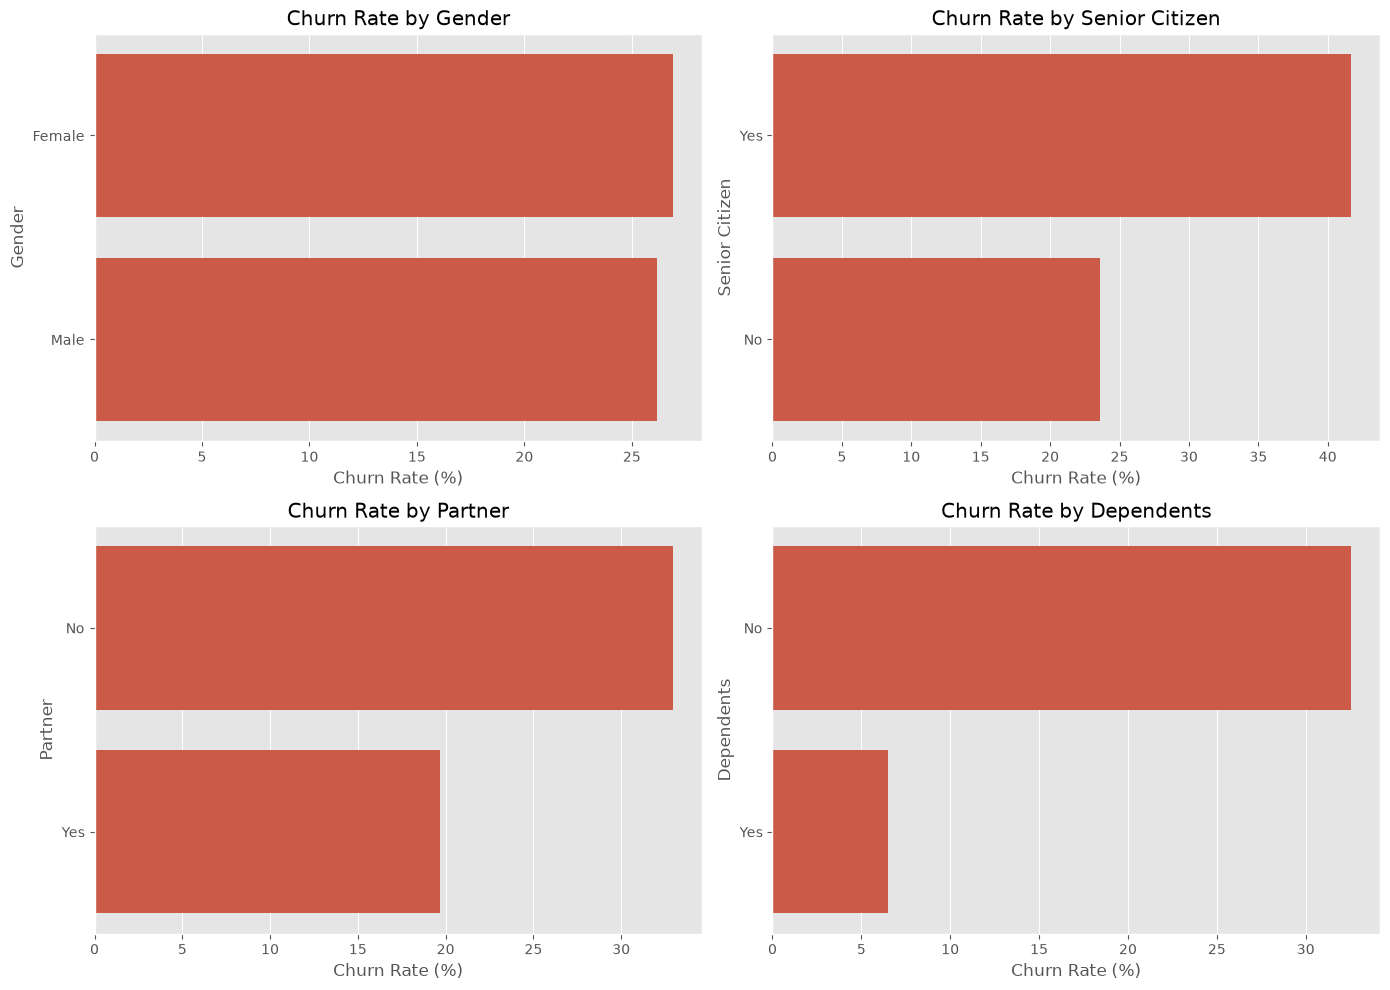

In [29]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 10)
)

for ax, (label, column) in zip(
    axes.flatten(),
    demographic_variables.items()
):
    
    churn_rate = churn_rate_by(column)
    
    sns.barplot(
        data=churn_rate,
        x="churn_rate",
        y=column,
        ax=ax
    )
    
    ax.set_title(f"Churn Rate by {label}")
    ax.set_xlabel("Churn Rate (%)")
    ax.set_ylabel(label)

plt.tight_layout()
plt.show()

## Demographic Analysis — Overall Findings

The demographic analysis indicates that customer churn is not equally
distributed across all customer groups.

The strongest demographic differences are observed for:

- Senior Citizen status
- Partner status
- Dependents status

Gender shows comparatively little difference in churn rate.

### Key Insight

Demographic characteristics may help identify customer segments with
different levels of churn risk, but demographic variables alone are not
sufficient to explain customer churn.

The analysis should therefore continue with behavioral and contractual
variables such as tenure, contract type, services, and billing behavior.

## 4. Tenure Analysis

### Business Question

**How does customer tenure relate to churn?**

Tenure represents the number of months a customer has remained with the
company.

Analyzing tenure can help determine whether customers are more vulnerable
to churn during the early stages of their relationship or after becoming
long-term customers.

### Objectives

- Understand the distribution of customer tenure.
- Compare tenure between churned and retained customers.
- Identify tenure ranges with higher churn rates.
- Identify whether new customers represent a high-risk segment.

In [30]:
df['tenure_months'].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure_months, dtype: float64

### 4.1 Overall Tenure Distribution

The distribution of tenure provides an overview of how long customers
typically remain with the company.

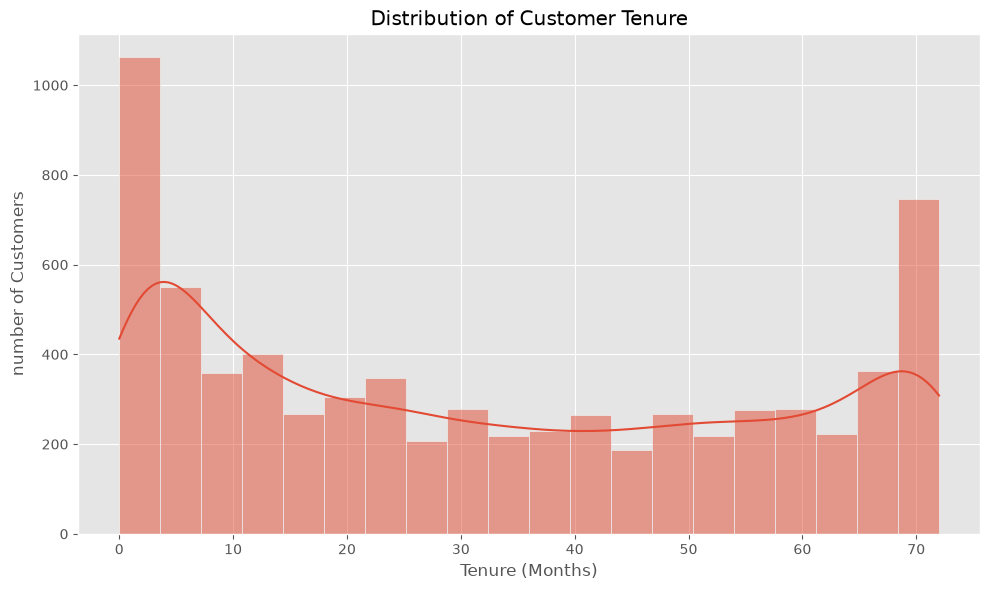

In [31]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x = 'tenure_months',
    bins = 20,
    kde = True
)
plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("number of Customers")

plt.tight_layout()
plt.show()

### 4.2 Tenure by Churn Status

### Business Question

**Do customers who churn have shorter tenure than customers who remain?**

Comparing tenure distributions by churn status can reveal whether customer
longevity is associated with retention.

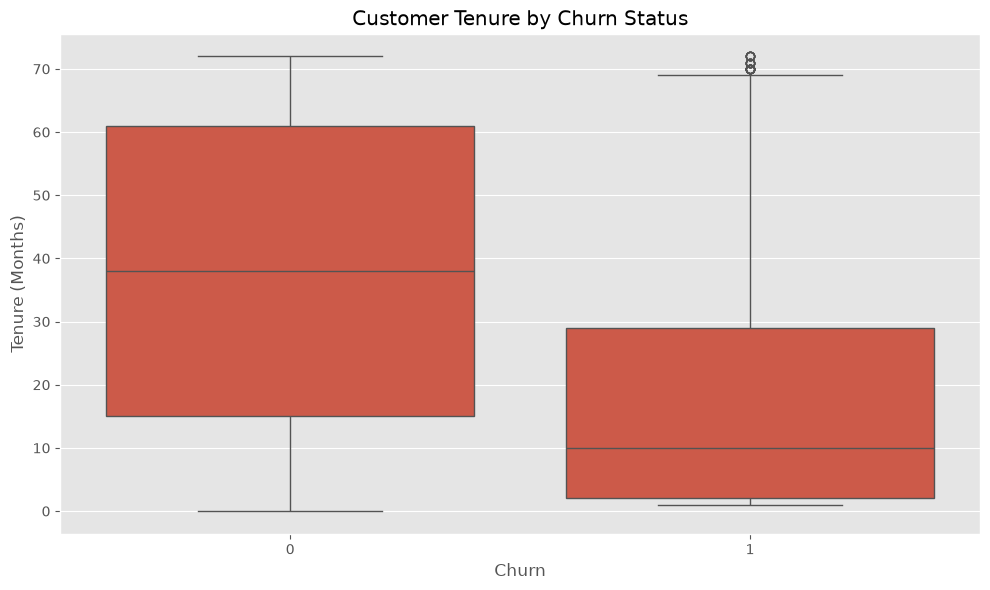

In [32]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x = 'churn_value',
    y='tenure_months'
)

plt.title("Customer Tenure by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.tight_layout()
plt.show()

### Finding

Customers who churn generally have substantially shorter tenure than
customers who remain with the company.

The median tenure of churned customers is considerably lower than that of
retained customers.

### Business Implication

Customer retention efforts should pay particular attention to the early
stages of the customer lifecycle.

The company may benefit from stronger onboarding, early engagement, and
proactive support during the first several months of a customer's
relationship.

In [42]:
# Creating tenure groups
df_copy = df.copy()
tenure_bins = [0, 6, 12, 24, 48, 60, 72]

tenure_labels = [
    "0-6 Months",
    "7-12 Months",
    "13-24 Months",
    "25-48 Months",
    "49-60 Months",
    "61-72 Months"
]

df_copy['tenure_groups'] = pd.cut(
    df['tenure_months'],
    bins=tenure_bins,
    labels=tenure_labels,
    include_lowest=True
)

In [44]:
df_copy["tenure_groups"].value_counts().sort_index()

tenure_groups
0-6 Months      1481
7-12 Months      705
13-24 Months    1024
25-48 Months    1594
49-60 Months     832
61-72 Months    1407
Name: count, dtype: int64

In [46]:
tenure_summary = (
    df_copy.groupby("tenure_groups", observed=True)
      .agg(
          customers=("customerid", "count"),
          churned_customers=(
              "churn_label",
              lambda x: (x == "Yes").sum()
          )
      )
)

tenure_summary["churn_rate"] = (
    tenure_summary["churned_customers"] /
    tenure_summary["customers"] * 100
).round(2)

tenure_summary

,customers,churned_customers,churn_rate
tenure_groups,,,
0-6 Months,1481,784,52.94
7-12 Months,705,253,35.89
13-24 Months,1024,294,28.71
25-48 Months,1594,325,20.39
49-60 Months,832,120,14.42
61-72 Months,1407,93,6.61


In [47]:
highest_tenure_churn = tenure_summary[
    "churn_rate"
].idxmax()

highest_tenure_rate = tenure_summary.loc[
    highest_tenure_churn,
    "churn_rate"
]

print(
    f"Highest churn group: {highest_tenure_churn}"
)

print(
    f"Churn rate: {highest_tenure_rate:.2f}%"
)

Highest churn group: 0-6 Months
Churn rate: 52.94%


In [49]:
# New Customer       = 0-12 months
# Established        = 13+ months

df_copy["customer_lifecycle"] = np.where(
    df["tenure_months"] <= 12,
    "New Customer",
    "Established Customer"
)

In [50]:
df_copy["customer_lifecycle"].value_counts()

customer_lifecycle
Established Customer    4857
New Customer            2186
Name: count, dtype: int64

In [52]:
lifecycle_summary = (
    df_copy.groupby("customer_lifecycle")
      .agg(
          customers=("customerid", "count"),
          churned_customers=(
              "churn_label",
              lambda x: (x == "Yes").sum()
          )
      )
)

lifecycle_summary["churn_rate"] = (
    lifecycle_summary["churned_customers"] /
    lifecycle_summary["customers"] * 100
).round(2)

lifecycle_summary

,customers,churned_customers,churn_rate
customer_lifecycle,,,
Established Customer,4857,832,17.13
New Customer,2186,1037,47.44


### Finding: Customer Lifecycle

The analysis shows a strong relationship between customer tenure and churn.

Customers in the early stages of their relationship with the company
generally have substantially higher churn rates than established
customers.

### Business Implication

The early customer lifecycle represents an important retention window.

Potential strategies include:

- Strengthening customer onboarding
- Providing proactive support during the first few months
- Monitoring new customers for early signs of dissatisfaction
- Offering incentives for customers approaching their first contract renewal
- Encouraging customers to adopt services that increase engagement

Retention efforts should therefore focus not only on identifying customers
who are likely to churn, but also on identifying the stage of the customer
relationship at which intervention is most effective.

## 5. Contract Analysis

### Business Question

**How does contract type relate to customer churn?**

Customers can have different levels of contractual commitment:

- Month-to-month
- One year
- Two year

The objective of this analysis is to determine whether customers with
different contract types exhibit different churn behavior.

### Objectives

- Understand the distribution of contract types.
- Calculate churn rates for each contract type.
- Compare customer tenure across contract types.
- Investigate the relationship between contract type and tenure.
- Identify potentially high-risk customer segments.

In [33]:
df['contract'].value_counts()

contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

### 5.1 Contract Distribution

Before examining churn, the distribution of customers across contract types
is examined.

Understanding the size of each contract segment is important because raw
churn counts can be misleading when groups have different customer
populations.

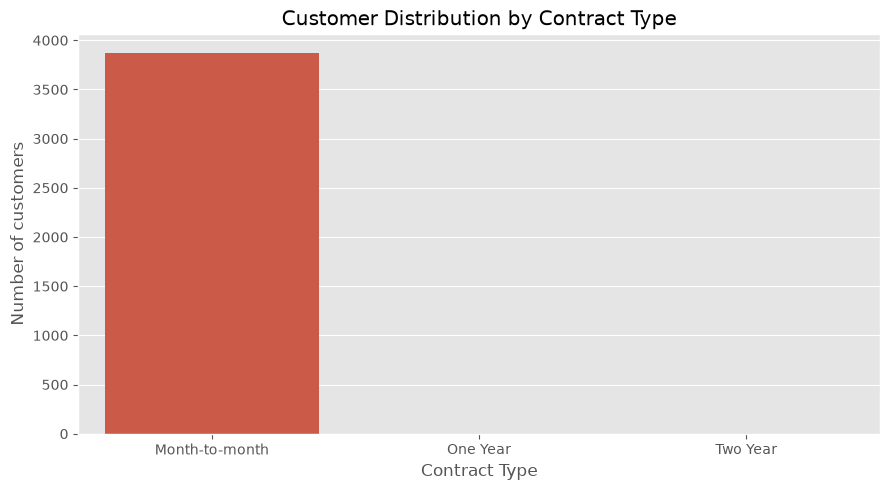

In [34]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x = 'contract',
    order = ['Month-to-month', 'One Year', 'Two Year']
)

plt.title("Customer Distribution by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of customers")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

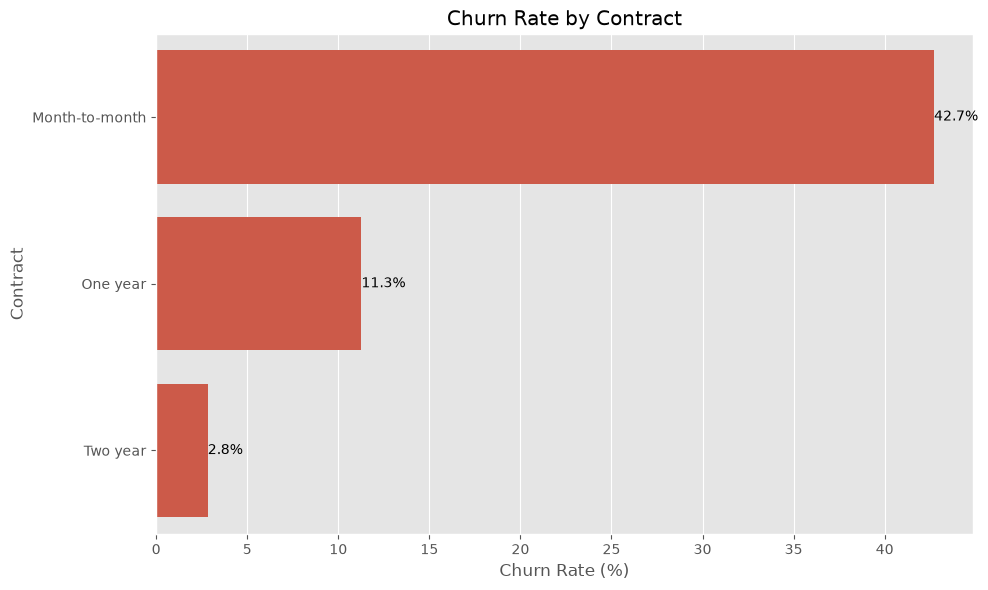

In [35]:
# Churn by contract type
plot_churn_rate('contract')

In [38]:
contract_summary = (
    df.groupby("contract")
      .agg(
          customers=("customerid", "count"),
          churned_customers=(
              "churn_label",
              lambda x: (x == "Yes").sum()
          )
      )
)

contract_summary["retained_customers"] = (
    contract_summary["customers"]
    - contract_summary["churned_customers"]
)

contract_summary["churn_rate"] = (
    contract_summary["churned_customers"]
    / contract_summary["customers"]
    * 100
).round(2)

contract_summary = contract_summary.reindex(
    ["Month-to-month", "One year", "Two year"]
)

contract_summary

,customers,churned_customers,retained_customers,churn_rate
contract,,,,
Month-to-month,3875,1655,2220,42.71
One year,1473,166,1307,11.27
Two year,1695,48,1647,2.83


In [39]:
highest_contract = contract_summary["churn_rate"].idxmax()
lowest_contract = contract_summary["churn_rate"].idxmin()

highest_rate = contract_summary.loc[
    highest_contract,
    "churn_rate"
]

lowest_rate = contract_summary.loc[
    lowest_contract,
    "churn_rate"
]

difference = highest_rate - lowest_rate

print(f"Highest churn contract: {highest_contract}")
print(f"Churn rate: {highest_rate:.2f}%")
print()
print(f"Lowest churn contract: {lowest_contract}")
print(f"Churn rate: {lowest_rate:.2f}%")
print()
print(f"Difference: {difference:.2f} percentage points")

Highest churn contract: Month-to-month
Churn rate: 42.71%

Lowest churn contract: Two year
Churn rate: 2.83%

Difference: 39.88 percentage points


### Finding: Contract Type and Churn

Contract type shows a substantial difference in customer churn.

Month-to-month customers have a considerably higher churn rate than
customers on one-year and two-year contracts. Customers on two-year
contracts have the lowest observed churn rate.

### Business Implication

Contract commitment appears to be strongly associated with customer
retention.

The business could investigate strategies that encourage month-to-month
customers to move toward longer-term contracts. Possible approaches
include:

- Contract upgrade incentives
- Discounts for annual commitments
- Loyalty benefits
- Renewal incentives
- Personalized offers for high-risk month-to-month customers

However, contract type should not be interpreted as the sole cause of
churn. Contract type may also be associated with tenure, pricing, services,
and customer characteristics.

### 5.2 Contract Type and Customer Tenure

### Business Question

**How does customer tenure differ across contract types?**

Contract type and tenure may be related. Customers who have remained with
the company for longer periods may be more likely to have longer-term
contracts.

Understanding this relationship helps avoid interpreting contract type
in isolation.

In [40]:
contract_tenure = (
    df.groupby("contract")["tenure_months"]
      .agg(
          customers="count",
          mean_tenure="mean",
          median_tenure="median",
          min_tenure="min",
          max_tenure="max"
      )
      .round(2)
      .reindex(
          ["Month-to-month", "One year", "Two year"]
      )
)

contract_tenure

,customers,mean_tenure,median_tenure,min_tenure,max_tenure
contract,,,,,
Month-to-month,3875,18.04,12.0,1,72
One year,1473,42.04,44.0,0,72
Two year,1695,56.74,64.0,0,72


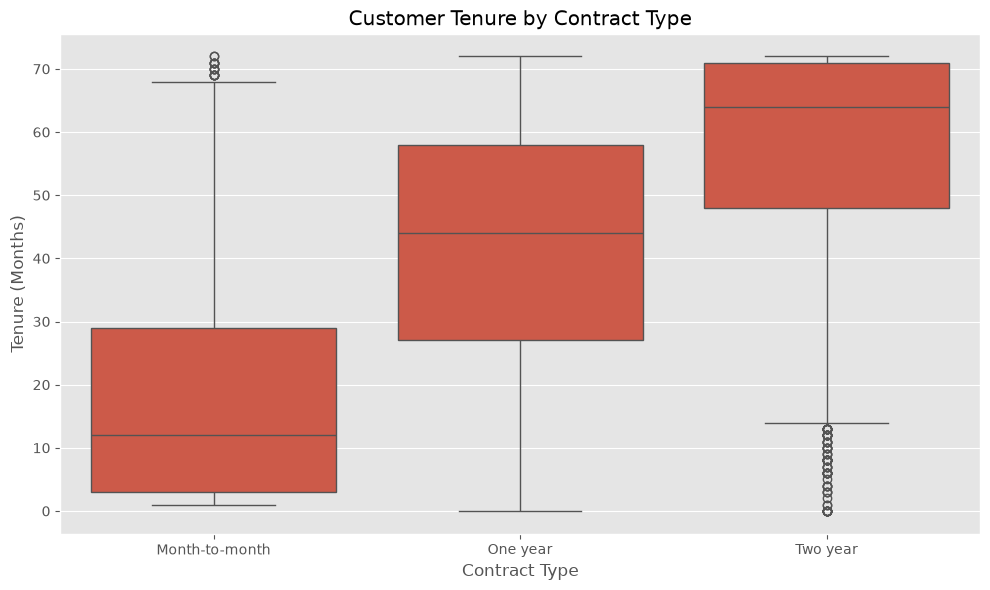

In [41]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="contract",
    y="tenure_months",
    order=["Month-to-month", "One year", "Two year"]
)

plt.title("Customer Tenure by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Tenure (Months)")

plt.tight_layout()
plt.show()

In [55]:
# Churn by contact type and tenure
contract_tenure_churn = (
    df_copy.groupby(
        ["contract", "tenure_groups"],
        observed=True
    )["churn_label"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="churn_rate")
)

contract_tenure_churn

,contract,tenure_groups,churn_rate
0,Month-to-month,0-6 Months,55.201699
1,Month-to-month,7-12 Months,41.996558
2,Month-to-month,13-24 Months,37.720488
3,Month-to-month,25-48 Months,32.917706
4,Month-to-month,49-60 Months,27.777778
5,Month-to-month,61-72 Months,22.222222
6,One year,0-6 Months,10.256410
7,One year,7-12 Months,10.588235
8,One year,13-24 Months,8.121827
9,One year,25-48 Months,10.617761


In [57]:
contract_tenure_pivot = contract_tenure_churn.pivot(
    index="tenure_groups",
    columns="contract",
    values="churn_rate"
)

contract_tenure_pivot = contract_tenure_pivot[
    ["Month-to-month", "One year", "Two year"]
]

contract_tenure_pivot.round(2)

contract,Month-to-month,One year,Two year
tenure_groups,,,
0-6 Months,55.20,10.26,0.00
7-12 Months,42.00,10.59,0.00
13-24 Months,37.72,8.12,0.00
25-48 Months,32.92,10.62,2.19
49-60 Months,27.78,13.71,3.97
61-72 Months,22.22,12.14,3.14


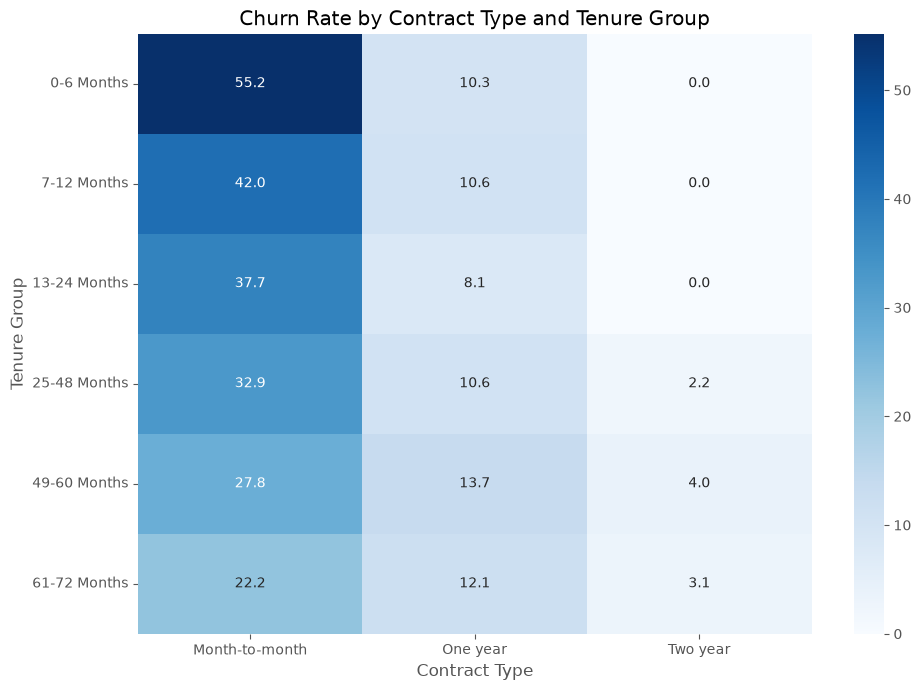

In [58]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    contract_tenure_pivot,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Churn Rate by Contract Type and Tenure Group")
plt.xlabel("Contract Type")
plt.ylabel("Tenure Group")

plt.tight_layout()
plt.show()

In [59]:
highest_risk_combination = contract_tenure_churn.loc[
    contract_tenure_churn["churn_rate"].idxmax()
]

highest_risk_combination

contract         Month-to-month
tenure_groups        0-6 Months
churn_rate            55.201699
Name: 0, dtype: object

In [61]:
print(
    "Highest observed contract-tenure churn segment:"
)

print(
    f"Contract: {highest_risk_combination['contract']}"
)

print(
    f"Tenure Group: {highest_risk_combination['tenure_groups']}"
)

print(
    f"Churn Rate: {highest_risk_combination['churn_rate']:.2f}%"
)

Highest observed contract-tenure churn segment:
Contract: Month-to-month
Tenure Group: 0-6 Months
Churn Rate: 55.20%


In [62]:
contract_tenure_summary = (
    df_copy.groupby(
        ["contract", "tenure_groups"],
        observed=True
    )
    .agg(
        customers=("customerid", "count"),
        churned_customers=(
            "churn_label",
            lambda x: (x == "Yes").sum()
        )
    )
)

contract_tenure_summary["churn_rate"] = (
    contract_tenure_summary["churned_customers"]
    / contract_tenure_summary["customers"]
    * 100
).round(2)

contract_tenure_summary = (
    contract_tenure_summary
    .reset_index()
)

contract_tenure_summary.sort_values(
    "churn_rate",
    ascending=False
).head(10)

,contract,tenure_groups,customers,churned_customers,churn_rate
0,Month-to-month,0-6 Months,1413,780,55.20
1,Month-to-month,7-12 Months,581,244,42.00
2,Month-to-month,13-24 Months,737,278,37.72
3,Month-to-month,25-48 Months,802,264,32.92
4,Month-to-month,49-60 Months,234,65,27.78
5,Month-to-month,61-72 Months,108,24,22.22
10,One year,49-60 Months,321,44,13.71
11,One year,61-72 Months,313,38,12.14
9,One year,25-48 Months,518,55,10.62
7,One year,7-12 Months,85,9,10.59


### Finding: Contract and Customer Lifecycle

Contract type shows a strong association with churn, with month-to-month
customers exhibiting substantially higher churn than customers on longer
contracts.

The analysis also shows that contract type should be considered alongside
customer tenure. New customers on month-to-month contracts represent an
important high-risk segment that warrants further investigation.

### Business Implication

Rather than applying retention strategies uniformly across the customer
base, the business could prioritize:

1. New month-to-month customers.
2. Month-to-month customers approaching early renewal decisions.
3. Customers showing other high-risk characteristics in addition to their
   contract type.

Potential interventions include targeted onboarding, proactive customer
support, personalized offers, and incentives to transition to longer-term
contracts.

Further analysis of services, billing, and payment behavior is required
before determining the specific reasons these customers churn.

## 6. Service Analysis

### Business Question

**How does service adoption relate to customer churn?**

Customers use different combinations of internet and additional services.
Understanding whether service usage is associated with different churn rates
can help identify potential retention opportunities.

### Services Analyzed

- Internet Service
- Online Security
- Online Backup
- Device Protection
- Tech Support
- Streaming TV
- Streaming Movies

### Objectives

- Understand the distribution of service adoption.
- Calculate churn rates for individual services.
- Compare churn between customers who use and do not use each service.
- Analyze the relationship between the number of services used and churn.
- Identify service-related patterns that may warrant further investigation.

In [64]:
service_columns = [
    "internetservice",
    "onlinesecurity",
    "onlinebackup",
    "deviceprotection",
    "techsupport",
    "streamingtv",
    "streamingmovies"
]

service_columns

['internetservice',
 'onlinesecurity',
 'onlinebackup',
 'deviceprotection',
 'techsupport',
 'streamingtv',
 'streamingmovies']

### 6.1 Internet Service

### Business Question

**Does the type of internet service relate to customer churn?**

Customers are classified into:

- DSL
- Fiber optic
- No internet service

In [65]:
df['internet_service'].value_counts()

internet_service
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

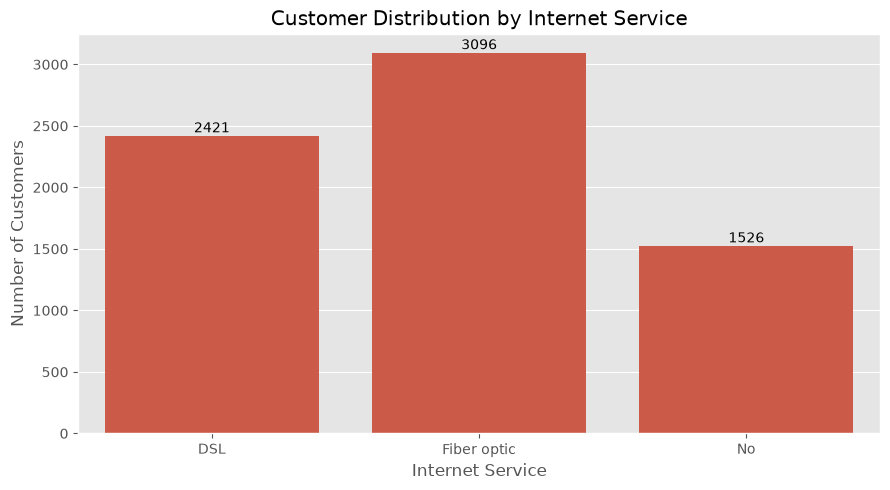

In [66]:
plt.figure(figsize=(9, 5))

ax = sns.countplot(
    data=df,
    x="internet_service"
)

plt.title("Customer Distribution by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [67]:
internet_service_churn = churn_rate_by(
    'internet_service'
)
internet_service_churn

churn_label,No,Yes,churn_rate
internet_service,,,
Fiber optic,0.581072,0.418928,41.892765
DSL,0.810409,0.189591,18.959108
No,0.925950,0.074050,7.404980


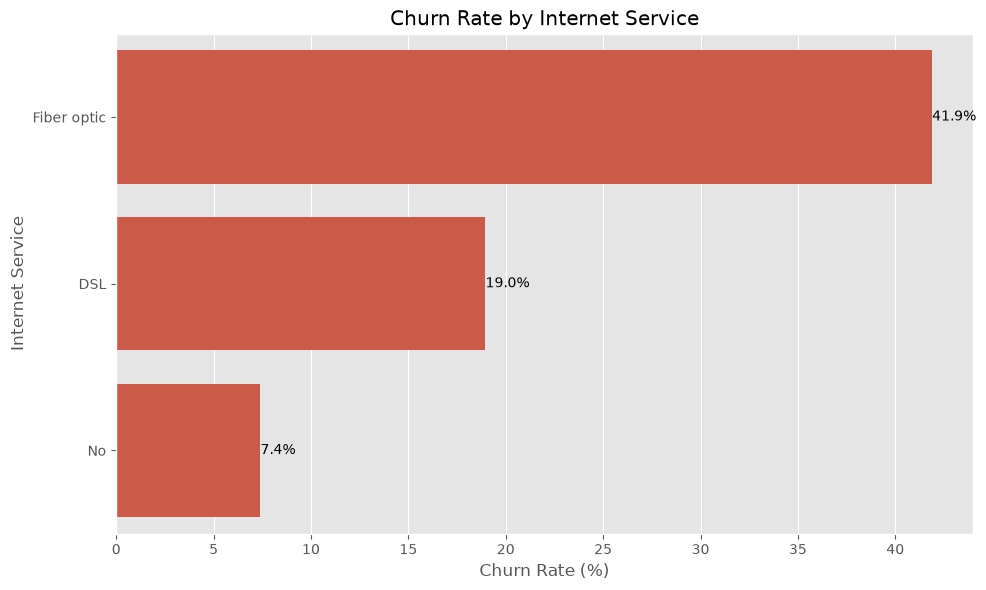

In [68]:
plot_churn_rate('internet_service')

### Finding

Churn rates vary considerably across internet service categories.

Fiber optic customers show a noticeably higher churn rate than DSL
customers, while customers without internet service have substantially
lower churn.

### Business Implication

Internet service type appears to be an important segmentation variable.

The higher churn observed among fiber-optic customers warrants further
investigation into related factors such as monthly charges, technical
support, service quality, and additional service adoption.

The observed relationship should not be interpreted as evidence that fiber
optic service itself causes churn.

In [69]:
additional_services = [
    "online_security",
    "online_backup",
    "device_protection",
    "tech_support",
    "streaming_tv",
    "streaming_movies"
]

for column in additional_services:
    print(f"\n{column}")
    print(df[column].value_counts())


online_security
online_security
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

online_backup
online_backup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

device_protection
device_protection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64

tech_support
tech_support
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64

streaming_tv
streaming_tv
No                     2810
Yes                    2707
No internet service    1526
Name: count, dtype: int64

streaming_movies
streaming_movies
No                     2785
Yes                    2732
No internet service    1526
Name: count, dtype: int64


In [70]:
service_churn_results = {}

for column in additional_services:
    service_churn_results[column] = churn_rate_by(column)
service_churn_results

{'online_security': churn_label                No       Yes  churn_rate
 online_security                                    
 No                   0.582333  0.417667   41.766724
 Yes                  0.853888  0.146112   14.611194
 No internet service  0.925950  0.074050    7.404980,
 'online_backup': churn_label                No       Yes  churn_rate
 online_backup                                      
 No                   0.600712  0.399288   39.928756
 Yes                  0.784685  0.215315   21.531494
 No internet service  0.925950  0.074050    7.404980,
 'device_protection': churn_label                No       Yes  churn_rate
 device_protection                                  
 No                   0.608724  0.391276   39.127625
 Yes                  0.774979  0.225021   22.502064
 No internet service  0.925950  0.074050    7.404980,
 'tech_support': churn_label                No       Yes  churn_rate
 tech_support                                       
 No                   0

In [73]:
service_binary_results = []

for column in additional_services:
    
    temp = (
        df[df[column].isin(["Yes", "No"])]
        .groupby(column)["churn_label"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .reset_index(name="churn_rate")
    )
    
    temp["service"] = column
    
    service_binary_results.append(temp)

service_binary_churn = pd.concat(
    service_binary_results,
    ignore_index=True
)

service_binary_churn

,online_security,churn_rate,service,online_backup,device_protection,tech_support,streaming_tv,streaming_movies
0,No,41.766724,online_security,NaN,NaN,NaN,NaN,NaN
1,Yes,14.611194,online_security,NaN,NaN,NaN,NaN,NaN
2,NaN,39.928756,online_backup,No,NaN,NaN,NaN,NaN
3,NaN,21.531494,online_backup,Yes,NaN,NaN,NaN,NaN
4,NaN,39.127625,device_protection,NaN,No,NaN,NaN,NaN
5,NaN,22.502064,device_protection,NaN,Yes,NaN,NaN,NaN
6,NaN,41.635474,tech_support,NaN,NaN,No,NaN,NaN
7,NaN,15.166341,tech_support,NaN,NaN,Yes,NaN,NaN
8,NaN,33.523132,streaming_tv,NaN,NaN,NaN,No,NaN
9,NaN,30.070188,streaming_tv,NaN,NaN,NaN,Yes,NaN


## 7. Billing & Payment Analysis

### Business Question

**How are billing characteristics and payment behavior associated with
customer churn?**

Billing-related variables can provide insight into customer price exposure,
payment preferences, and potential friction in the customer relationship.

### Variables Analyzed

- Monthly Charges
- Total Charges
- Payment Method
- Paperless Billing
- Contract Type

### Objectives

- Understand the distribution of monthly and total charges.
- Compare charges between churned and retained customers.
- Analyze churn rates across payment methods.
- Analyze churn by paperless billing status.
- Investigate the relationship between monthly charges and contract type.
- Identify potentially high-risk billing segments.

In [81]:
df['monthly_charges'].describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: monthly_charges, dtype: float64

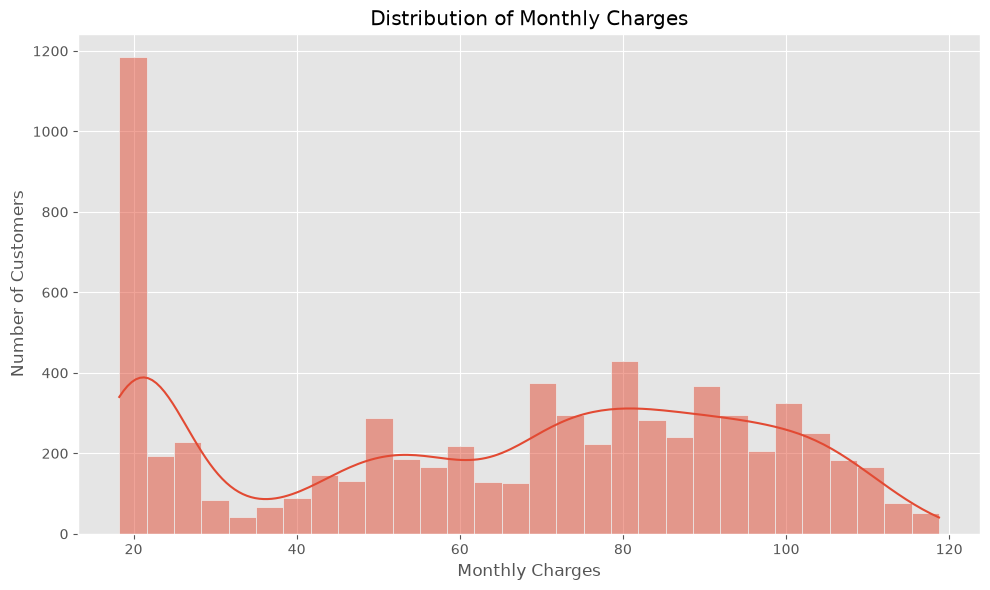

In [83]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="monthly_charges",
    bins=30,
    kde=True
)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

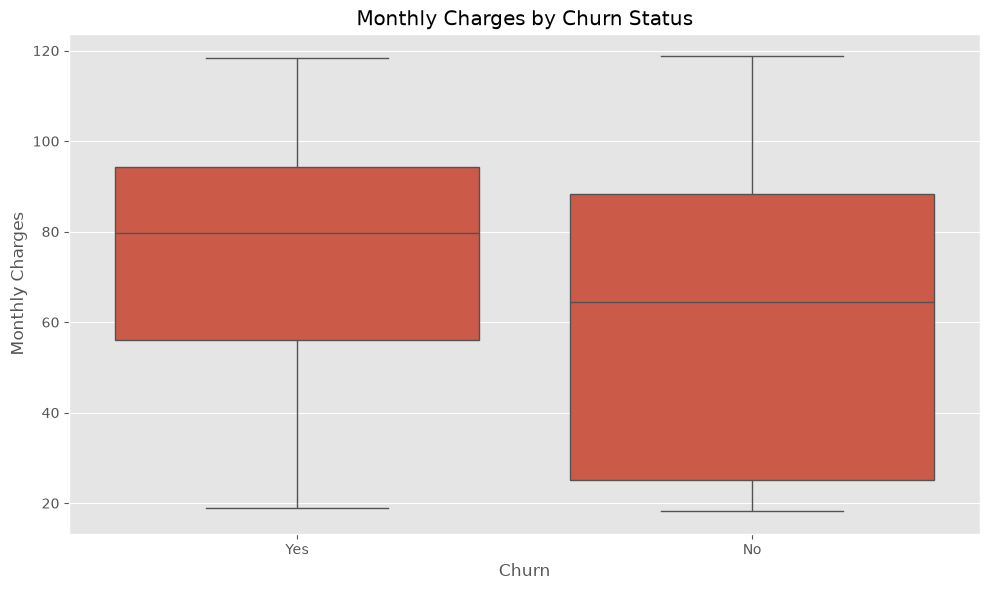

In [84]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="churn_label",
    y="monthly_charges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.tight_layout()
plt.show()

In [85]:
monthly_charge_churn = (
    df.groupby("churn_label")["monthly_charges"]
      .agg(
          customers="count",
          mean="mean",
          median="median",
          min="min",
          max="max"
      )
      .round(2)
)

monthly_charge_churn

,customers,mean,median,min,max
churn_label,,,,,
No,5174,61.27,64.43,18.25,118.75
Yes,1869,74.44,79.65,18.85,118.35


### Finding: Monthly Charges

Churned customers show different monthly charge characteristics compared
with retained customers.

The observed difference suggests that monthly pricing may be associated
with churn behavior.

### Business Implication

Customers with higher monthly charges may represent a segment worth
investigating for price sensitivity.

However, monthly charges should not be interpreted independently because
higher charges may also be associated with:

- Internet service type
- Number of services
- Contract type
- Customer tenure

Further analysis is therefore required before concluding that pricing is a
primary driver of churn.

In [86]:
contract_monthly_charges = (
    df.groupby("contract")["monthly_charges"]
      .agg(
          mean="mean",
          median="median",
          min="min",
          max="max"
      )
      .round(2)
      .reindex(
          ["Month-to-month", "One year", "Two year"]
      )
)

contract_monthly_charges

,mean,median,min,max
contract,,,,
Month-to-month,66.40,73.25,18.75,117.45
One year,65.05,68.75,18.25,118.60
Two year,60.77,64.35,18.40,118.75


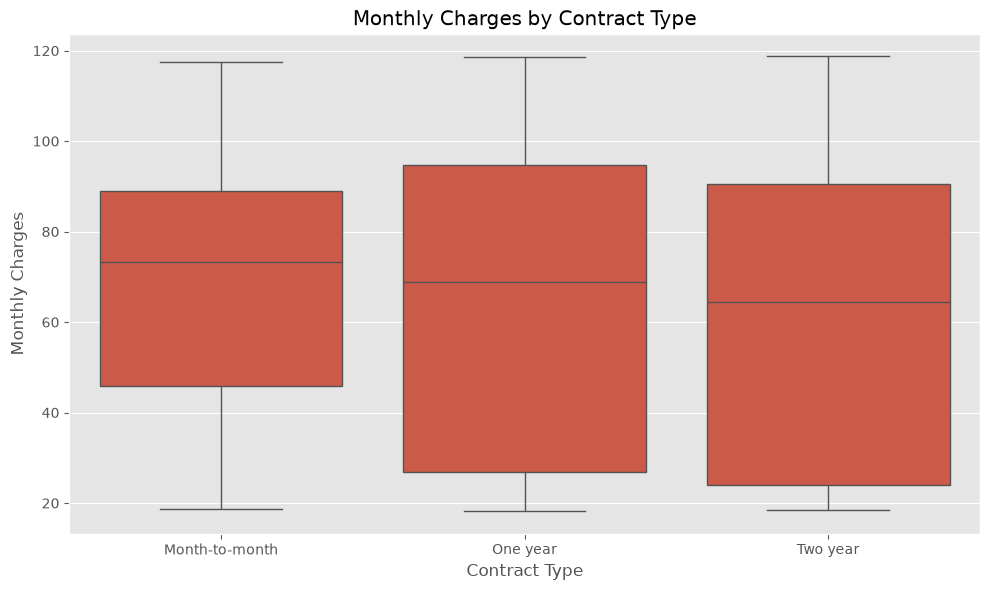

In [87]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="contract",
    y="monthly_charges",
    order=[
        "Month-to-month",
        "One year",
        "Two year"
    ]
)

plt.title("Monthly Charges by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Monthly Charges")

plt.tight_layout()
plt.show()

In [88]:
df["total_charges"].describe()

count    7043.000000
mean     2279.734304
std      2266.794470
min         0.000000
25%       398.550000
50%      1394.550000
75%      3786.600000
max      8684.800000
Name: total_charges, dtype: float64

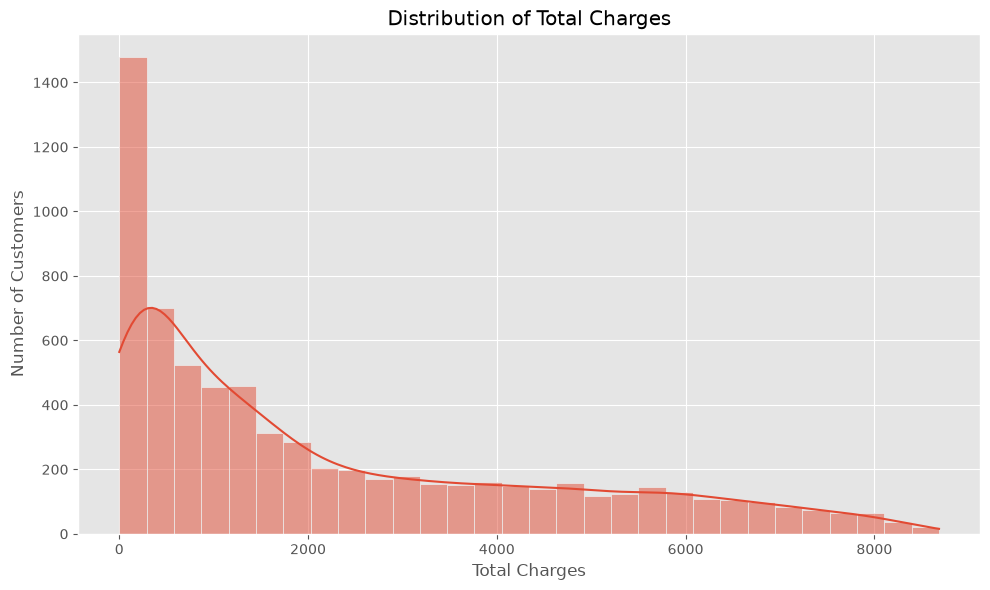

In [89]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="total_charges",
    bins=30,
    kde=True
)

plt.title("Distribution of Total Charges")
plt.xlabel("Total Charges")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

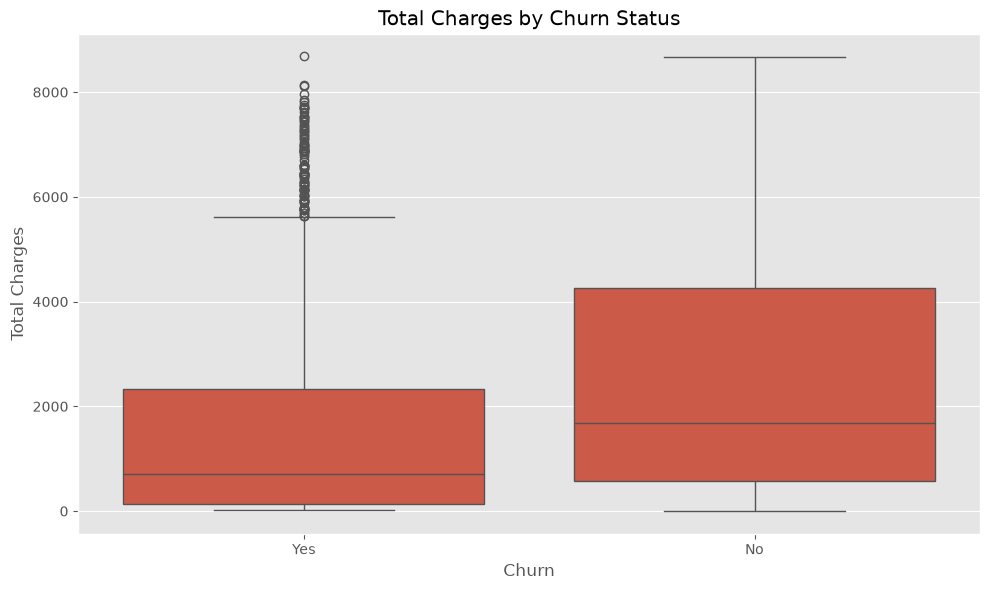

In [91]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="churn_label",
    y="total_charges"
)

plt.title("Total Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Total Charges")

plt.tight_layout()
plt.show()

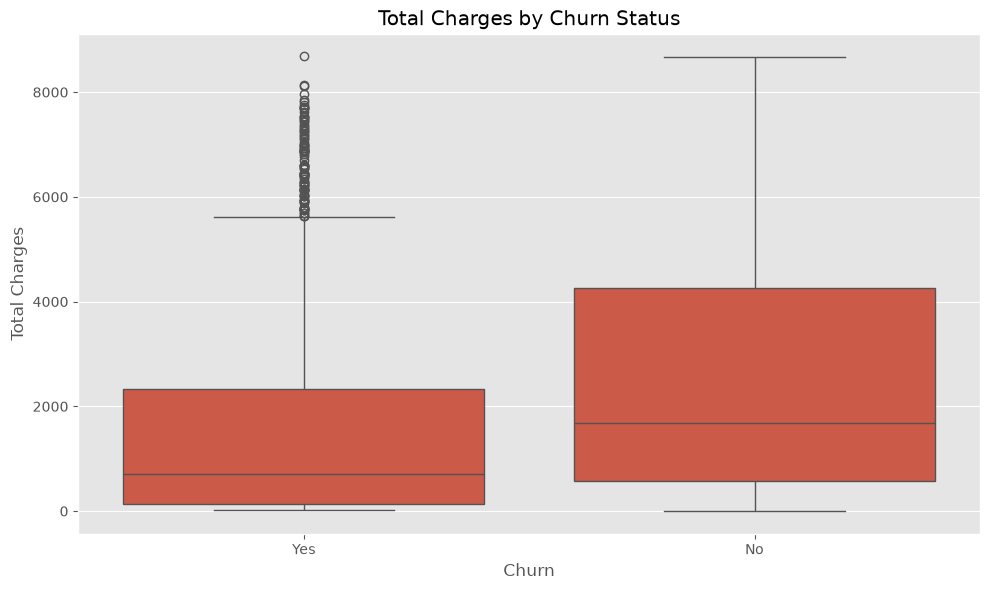

In [92]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="churn_label",
    y="total_charges"
)

plt.title("Total Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Total Charges")

plt.tight_layout()
plt.show()

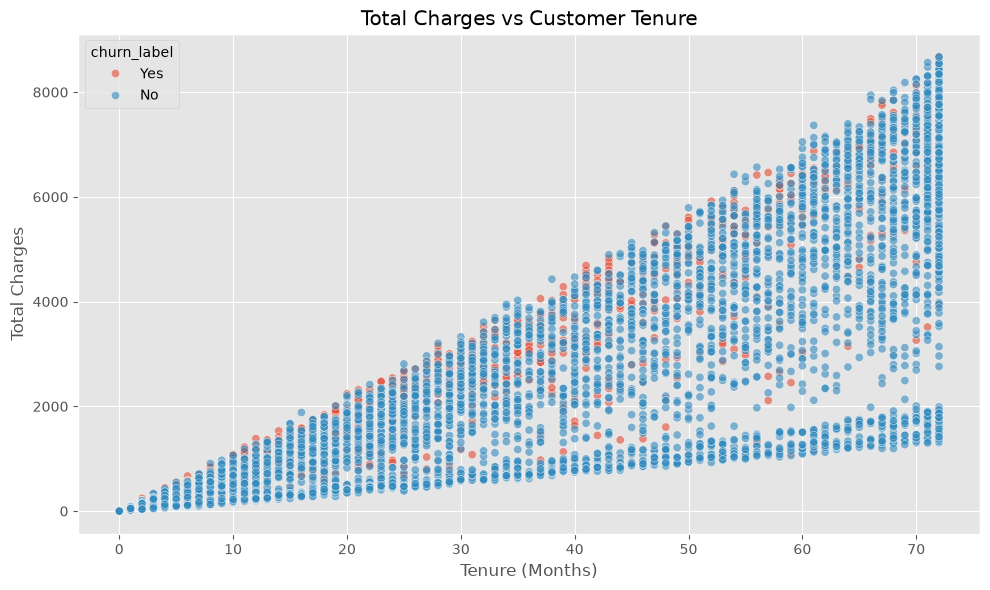

In [95]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="tenure_months",
    y="total_charges",
    hue="churn_label",
    alpha=0.6
)

plt.title("Total Charges vs Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Total Charges")

plt.tight_layout()
plt.show()

In [96]:
df["payment_method"].value_counts()

payment_method
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

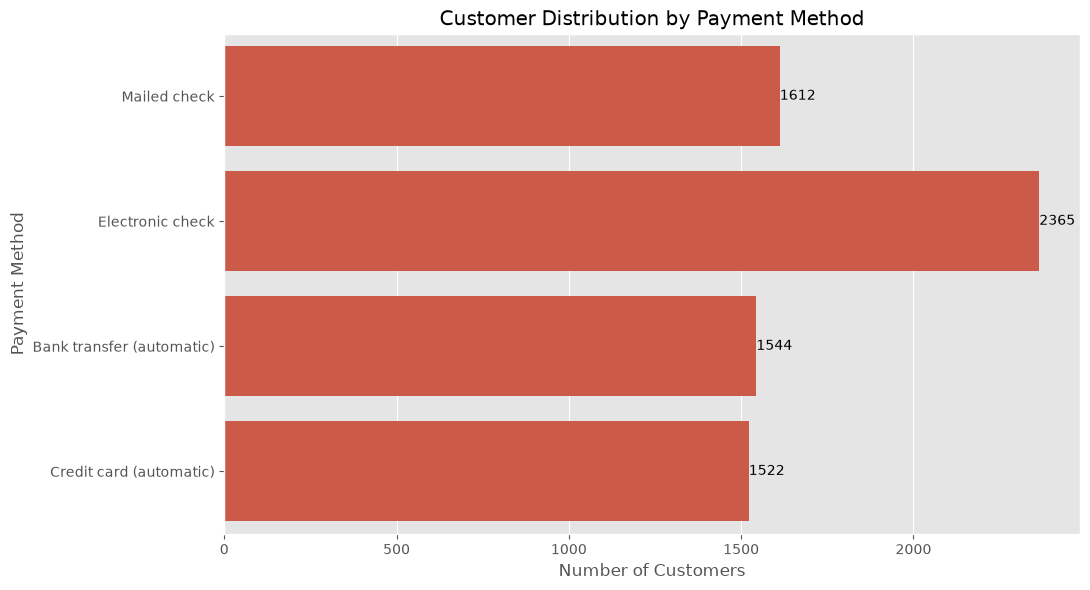

In [97]:
plt.figure(figsize=(11, 6))

ax = sns.countplot(
    data=df,
    y="payment_method"
)

plt.title("Customer Distribution by Payment Method")
plt.xlabel("Number of Customers")
plt.ylabel("Payment Method")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [99]:
payment_churn = churn_rate_by('payment_method')
payment_churn

churn_label,No,Yes,churn_rate
payment_method,,,
Electronic check,0.547146,0.452854,45.285412
Mailed check,0.808933,0.191067,19.106700
Bank transfer (automatic),0.832902,0.167098,16.709845
Credit card (automatic),0.847569,0.152431,15.243101


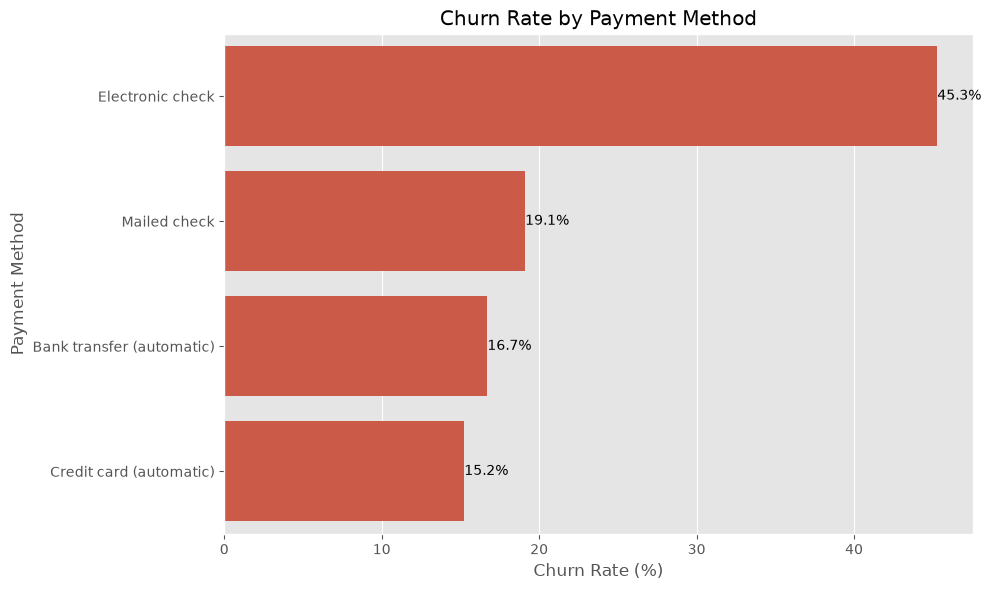

In [100]:
plot_churn_rate('payment_method')

In [101]:
payment_summary = (
    df.groupby("payment_method")
      .agg(
          customers=("customerid", "count"),
          churned_customers=(
              "churn_label",
              lambda x: (x == "Yes").sum()
          )
      )
)

payment_summary["churn_rate"] = (
    payment_summary["churned_customers"]
    / payment_summary["customers"]
    * 100
).round(2)

payment_summary.sort_values(
    "churn_rate",
    ascending=False
)

,customers,churned_customers,churn_rate
payment_method,,,
Electronic check,2365,1071,45.29
Mailed check,1612,308,19.11
Bank transfer (automatic),1544,258,16.71
Credit card (automatic),1522,232,15.24


### Finding: Payment Method

Churn rates vary considerably across payment methods.

Electronic check customers generally exhibit higher churn than customers
using automatic payment methods.

### Business Implication

Payment method may be a useful indicator of customer churn risk.

The business could investigate whether customers using manual payment
methods experience greater payment friction or have different customer
characteristics.

Potential strategies include:

- Promoting automatic payment options
- Simplifying payment setup
- Providing incentives for automatic payments
- Monitoring customers who repeatedly use manual payment methods

However, payment method may also be correlated with contract type,
tenure, and customer demographics, so it should not be treated as a
standalone causal factor.

## Billing & Payment Analysis — Overall Findings

The billing analysis reveals several important patterns:

1. Monthly charges differ between churned and retained customers.
2. Total charges are strongly related to tenure and should therefore not
   be interpreted independently.
3. Payment method shows meaningful differences in observed churn rates.
4. Paperless billing status is associated with differences in churn.
5. Monthly charges and contract type should be analyzed together rather
   than independently.
6. Month-to-month customers with relatively high monthly charges represent
   a potentially important high-risk segment.

### Key Insight

Billing characteristics provide useful signals for identifying customers
with different levels of churn risk. However, billing variables are
interconnected with contract type, tenure, services, and customer
characteristics.

The strongest conclusions should therefore come from analyzing these
variables together rather than treating any individual billing variable as
a direct cause of churn.

## EDA Finding Log

| Analysis | Finding | Business Implication |
|---|---|---|
| Overall Churn | Approximately one in four customers has churned. | Customer retention represents a significant business opportunity. |
| Senior Citizen | Senior citizens have a higher churn rate compared with non-senior customers. | The company could consider developing targeted support and retention strategies for senior customers.|
| Partner | Customers without a partner show a higher churn rate than customers who have a partner. | Partner status may act as an indicator of customer stability or customer lifecycle stage. |
| Dependents | Customers without dependents have a higher churn rate than customers with dependents. | Customers without dependents may represent a higher-risk segment.
| Tenure | Customer retention efforts should pay particular attention to the early stages of the customer lifecycle. | The company may benefit from stronger onboarding, early engagement, and proactive support during the first several months of a customer's relationship.
| Contract Type | Month-to-month customers have substantially higher churn than one-year and two-year customers. | Retention strategies should prioritize month-to-month customers and investigate incentives for longer-term contracts. |
| Contract + Tenure | Contract type and tenure together provide a more detailed view of churn risk. | New month-to-month customers represent an important segment for proactive retention. |
| Service Analysis | Churn rates vary across internet service categories, with fiber optic customers showing comparatively high churn. | Investigate pricing, support, and service experience among high-churn internet segments. |
| Additional Services | Churn rates differ between customers who adopt additional services and those who do not. | Service adoption may provide opportunities for customer engagement and retention. |
| Service Engagement | Churn behavior varies with the number of additional services used. | Investigate whether increasing relevant customer engagement is associated with improved retention. |
| Billing | Churned and retained customers show different monthly charge characteristics. | Investigate price sensitivity while considering contract and service differences. |
| Payment Method | Churn rates vary across payment methods, with manual payment methods showing higher observed churn. | Investigate payment friction and opportunities to promote automatic payments. |